In [268]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc

In [269]:
class option_market:
    def __init__(self,S0,sigma,r,delta):
        self.S0 = S0
        self.sigma = sigma
        self.r = r
        self.delta = delta
    
    def crr_opt_eur(self,T,K,N,payoff_func):
        S0 =  self.S0 
        sigma =self.sigma 
        r = self.r
        delta = self.delta 
        delta_t = T/N
        delta_t = T/N

        u = np.exp(sigma*np.sqrt(delta_t))
        d = 1/u
        q_u = (np.exp((r-delta)*delta_t)-d)/(u-d)
        q_d = 1-q_u 
        endpoints = np.full(shape=(N+1,N+1),fill_value=np.nan)
        ends = lambda i,j : S0* u**(j-i) * d**i
        for n in range(N+1):
            for i in range(n+1):
                endpoints[i,n]=ends(i,n)

        p = np.full(shape=(N+1,N+1),fill_value=np.nan)
        for i in range(N,-1,-1):
            for j in range(i+1):
                p[j,i] = payoff_func(endpoints[j,i],K)

        v = np.full(shape=(N+1,N+1),fill_value=np.nan)
        for i in range(N-1,-1,-1):
            for j in range(i+1):
                if i == N-1:
                    v[j,i] =np.exp(-r*delta_t)*(q_u*p[j,i+1]+q_d*p[j+1,i+1])
                else:
                    v[j,i] = np.exp(-r*delta_t)*(q_u*v[j,i+1]+q_d*v[j+1,i+1])
        v[:,N] = payoff_func(endpoints[:,N],K)

        
        return v,endpoints

    def crr_opt_am(self,T,K,N,payoff_func):
            
        S0 =  self.S0 
        sigma =self.sigma 
        r = self.r
        delta = self.delta 
        delta_t = T/N
        delta_t = T/N

        u = np.exp(sigma*np.sqrt(delta_t))
        d = 1/u
        q_u = (np.exp((r-delta)*delta_t)-d)/(u-d)
        q_d = 1-q_u 
        endpoints = np.full(shape=(N+1,N+1),fill_value=np.nan)
        ends = lambda i,j : S0* u**(j-i) * d**i
        for n in range(N+1):
            for i in range(n+1):
                endpoints[i,n]=ends(i,n)

        p = np.full(shape=(N+1,N+1),fill_value=np.nan)
        for i in range(N,-1,-1):
            for j in range(i+1):
                p[j,i] = payoff_func(endpoints[j,i],K)

        v = np.full(shape=(N+1,N+1),fill_value=np.nan)
        for i in range(N-1,-1,-1):
            for j in range(i+1):
                if i == N-1:
                    v[j,i] = np.maximum(p[j,i],np.exp(-r*delta_t)*(q_u*p[j,i+1]+q_d*p[j+1,i+1]))
                else:
                    v[j,i] = np.maximum(p[j,i],np.exp(-r*delta_t)*(q_u*v[j,i+1]+q_d*v[j+1,i+1])) 
        v[:,N] = payoff_func(endpoints[:,N],K)
        return v,endpoints

In [291]:
put = lambda S,K : np.maximum(K-S,0)

T = 1/2; N = 1_000; K =100

market1 = option_market(S0=100,sigma=0.2,r=0.02,delta=0.01)

eur_put,s = market1.crr_opt_eur(T=T,K=K,N=N,payoff_func=put)
am_put,s = market1.crr_opt_am(T=T,K=K,N=N,payoff_func=put)
EEP_put = am_put-eur_put

In [292]:
print(eur_put[0,0])
print(am_put[0,0])

5.349053434106795
5.389438278115097


### 3

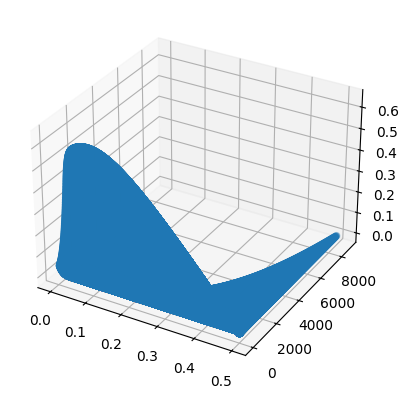

In [293]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(np.arange(s.shape[0])*(T/N),s,EEP_put)
plt.show()

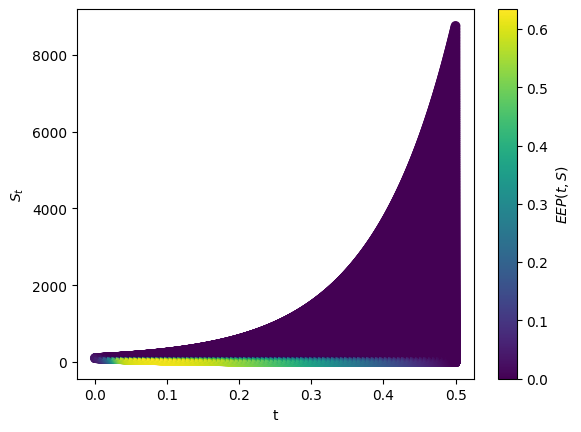

In [294]:
t = np.arange(s.shape[0]) * (T / N)

sc = plt.scatter(
    np.repeat(t, s.shape[0]),
    s.T,                
    c=EEP_put.T,      
    cmap="viridis"
)
cbar = plt.colorbar(sc)
plt.xlabel("t"); plt.ylabel(f"$S_t$"), cbar.set_label("$EEP(t,S)$")
plt.show()

**Comments**

* This is pretty intuitive, under "low enough" stock prices w.r.t. time and strike price the put is more valuable, hence the value of the american put is higher there.

### 4


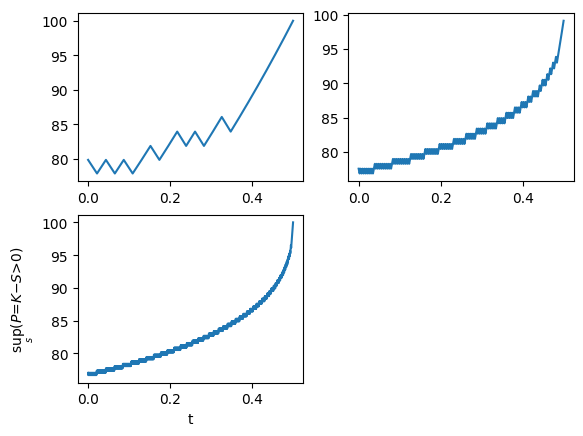

In [309]:
T = 1/2; N = 1_000; K =100

market1 = option_market(S0=100,sigma=0.2,r=0.02,delta=0.01)
i = 1
for N in [i**5 for i in range(2,5)]:
    eur_put,s = market1.crr_opt_eur(T=T,K=K,N=N,payoff_func=put)
    am_put,s = market1.crr_opt_am(T=T,K=K,N=N,payoff_func=put) 
    s_exb = []
    payoff = put(s,K)
    for t in range(N+1):
        mask =(am_put[:,t] == payoff[:,t])&(payoff[:,t]>0)
        if np.any(mask):
            s_exb.append(np.nanmax(np.where(mask,s[:,t],np.nan)))
    plt.subplot(2,2,i)
    x_axis = np.linspace(0, T, len(s_exb))
    plt.plot(x_axis,s_exb)
    i+=1
plt.xlabel("t")
plt.ylabel(fr"$\sup_s (P = K-S > 0)$")
plt.show()



**Comments**
* Roughly speaking evaluates the granularity of CRR pricing model, as $N\to\infty$, the "saw-like" steps get smoothed out.